In [1]:
import json
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = pathlib.Path("..")
RESULTS_DIR = ROOT / "results" / "linguistic_bert" / "message"
DIMS = ["conviction", "anchoring", "dialogic"]

In [2]:
rows = []
for f in RESULTS_DIR.glob("**/*.json"):
    rows.extend(json.loads(f.read_text()))
df = pd.DataFrame(rows)
print(f"{len(df):,} rows | topologies: {df['topology'].value_counts().to_dict()}")
df.head()

45,228 rows | topologies: {'fc': 36512, 'star': 8716}


,dataset,topology,W,qid,rep_idx,round,agent_idx,agent_id,conviction,anchoring,dialogic
0,gpqa,star,1,84,0,0,0,0,1,1,1
1,gpqa,star,1,84,0,1,0,0,1,5,1
2,gpqa,star,1,84,0,0,1,1,1,5,1
3,gpqa,star,1,84,0,1,1,1,1,5,1
4,gpqa,star,1,84,0,0,2,2,1,1,1


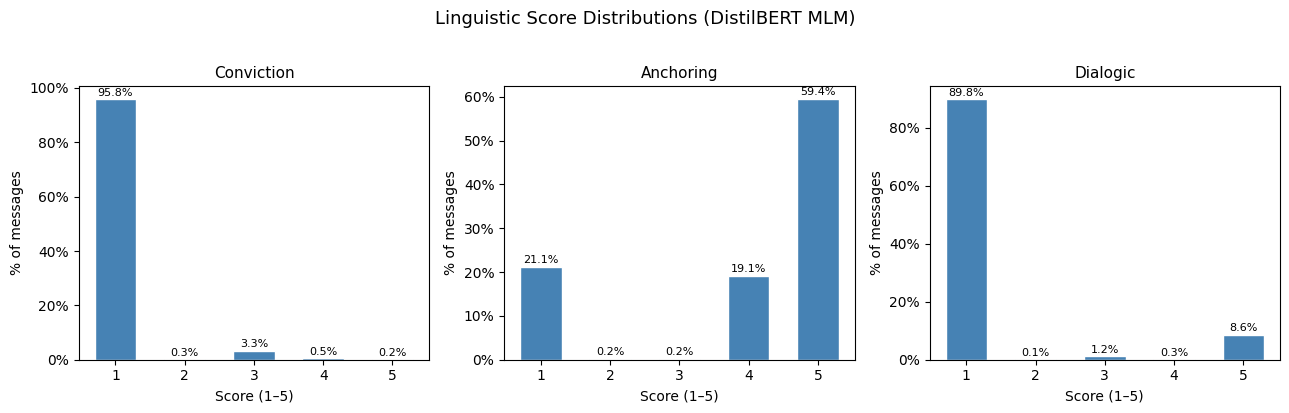

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Linguistic Score Distributions (DistilBERT MLM)", fontsize=13, y=1.02)

for ax, dim in zip(axes, DIMS):
    counts = df[dim].value_counts().sort_index()
    pct = counts / counts.sum() * 100
    bars = ax.bar(pct.index, pct.values, color="steelblue", edgecolor="white", width=0.6)
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("% of messages")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    for bar, v in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

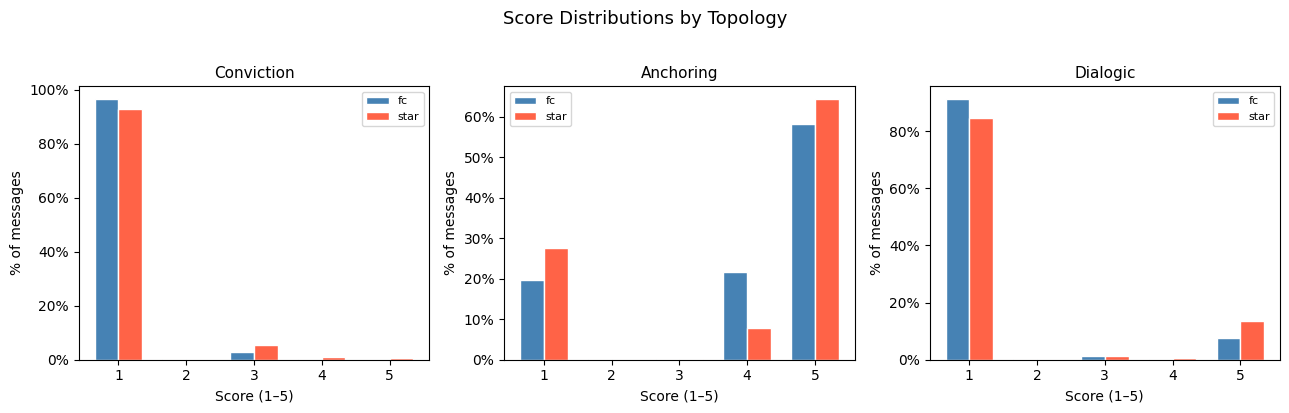

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
fig.suptitle("Score Distributions by Topology", fontsize=13, y=1.02)

colors = {"fc": "steelblue", "star": "tomato"}
width = 0.35
topos = sorted(df["topology"].unique())

for ax, dim in zip(axes, DIMS):
    for i, topo in enumerate(topos):
        sub = df[df["topology"] == topo]
        counts = sub[dim].value_counts().reindex([1,2,3,4,5], fill_value=0)
        pct = counts / counts.sum() * 100
        offset = (i - len(topos) / 2 + 0.5) * width
        ax.bar([x + offset for x in pct.index], pct.values,
               width=width, label=topo, color=colors.get(topo), edgecolor="white")
    ax.set_title(dim.capitalize(), fontsize=11)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("% of messages")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
print("=== Summary statistics ===")
print(df[DIMS].describe().round(2))
print("\n=== Value counts ===")
for dim in DIMS:
    vc = df[dim].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print(f"\n{dim}:")
    print(pd.DataFrame({"n": vc, "%": pct}))

=== Summary statistics ===
       conviction  anchoring  dialogic
count    45228.00   45228.00  45228.00
mean         1.09       3.96      1.38
std          0.44       1.58      1.15
min          1.00       1.00      1.00
25%          1.00       4.00      1.00
50%          1.00       5.00      1.00
75%          1.00       5.00      1.00
max          5.00       5.00      5.00

=== Value counts ===

conviction:
                n     %
conviction             
1           43334  95.8
2             131   0.3
3            1476   3.3
4             215   0.5
5              72   0.2

anchoring:
               n     %
anchoring             
1           9546  21.1
2             80   0.2
3            102   0.2
4           8618  19.1
5          26882  59.4

dialogic:
              n     %
dialogic             
1         40634  89.8
2            35   0.1
3           533   1.2
4           117   0.3
5          3909   8.6
